Cookie Sales Performance Dashboard 

1.  Project Overview
This project focuses on building an interactive Jupyter notebook dashboard to analyze cookie sales data.
The dashboard provides insights into revenue, cost, customer behavior, and product performance using multiple datasets.

2. Project Objective
- To analyze sales performance of different cookie types  
- To track revenue, cost, and profit  
- To understand customer distribution  
- To build an interactive dashboard  
- To integrate Python visual  

3. Business Requirement
The business wants to:
- Identify top-performing cookie products
- Monitor sales trends over time
- Analyze customer distribution by location
- Track key metrics like revenue, cost, and profit
- Enable interactive filtering for better decision-making

4. Data Source
The project uses three datasets:
- Orders dataset (transaction-level data)
- Customers dataset (customer details)
- Cookie Types dataset (product-level information)

5. Data Preparation and Cleaning
- Removed inconsistencies using Trim and Clean functions
- Verified correct data types (Date, Numeric fields)
- Checked and handled missing values
- Ensured consistent naming across tables

6. Data Modelling
A star schema model was created:
- Orders table as the central fact table
- Customers and Cookie Types as dimension tables
Relationships:
- Customers[Customer ID] → Orders[Customer ID]
- Cookie Types[Cookie Type] → Orders[Product]
Both relationships are One-to-Many with single-direction filtering.

7. Key Measures
- Total Revenue = orders['Revenue'].sum()
- Total Cost = orders['Cost'].sum()
- Profit = Total Revenue – Total Cost
- Total Orders = orders['Order ID'].nunique()
- Avg Order Value = Total Revenue / Total Orders

8. Dashboard Development
The dashboard includes:
- KPI cards for Revenue, Cost, Orders, and Average Order Value
- Bar chart showing revenue by cookie type
- Line chart showing sales trends over time
- Donut chart showing order distribution by city
- Pie chart comparing revenue and cost
- Interactive filters for cookie type and city
  
Interactive filters:
- Cookie Type
- City

In [31]:
import pandas as pd
import numpy as np
import plotly.express as px # pyright: ignore[reportMissingImports]
import plotly.graph_objects as go # pyright: ignore[reportMissingImports]
import ipywidgets as widgets # pyright: ignore[reportMissingImports]
from IPython.display import display, Markdown

In [32]:
import pandas as pd

base_path = r"C:\Users\Hp\Desktop\Projects\GitHub Projects\Cookie sales analysis\Data"

orders = pd.read_excel(base_path + r"\Orders 1.xlsx")
customers = pd.read_excel(base_path + r"\Customers 1.xlsx")
cookie_types = pd.read_excel(base_path + r"\Cookie Types 1.xlsx")

print("Orders columns:", orders.columns.tolist())
print("Customers columns:", customers.columns.tolist())
print("Cookie Types columns:", cookie_types.columns.tolist())

Orders columns: ['Customer ID', 'Order ID', 'Product', 'Units Sold', 'Date', 'Revenue', 'Cost']
Customers columns: ['Customer ID', 'Name', 'Phone', 'Address', 'City', 'State', 'Zip', 'Country', 'Notes']
Cookie Types columns: ['Cookie Type', 'Units Sold', 'Revenue Per Cookie', 'Cost Per Cookie']


In [33]:
import pandas as pd
import os

# STEP 1: Set your correct folder path
base_path = r"C:\Users\Hp\Desktop\Projects\GitHub Projects\Cookie sales analysis\Data"

# STEP 2: (Optional but IMPORTANT) Verify files exist
print("Files in folder:", os.listdir(base_path))

# STEP 3: Load files using full path
orders = pd.read_excel(base_path + r"\Orders 1.xlsx")
customers = pd.read_excel(base_path + r"\Customers 1.xlsx")
cookie_types = pd.read_excel(base_path + r"\Cookie Types 1.xlsx")

# STEP 4: Clean column names
orders.columns = orders.columns.str.strip()
customers.columns = customers.columns.str.strip()
cookie_types.columns = cookie_types.columns.str.strip()

# STEP 5: Fix data types (correct column names)
orders['Date'] = pd.to_datetime(orders['Date'], errors='coerce')
orders['Revenue'] = pd.to_numeric(orders['Revenue'], errors='coerce').fillna(0)
orders['Cost'] = pd.to_numeric(orders['Cost'], errors='coerce').fillna(0)
orders['Units Sold'] = pd.to_numeric(orders['Units Sold'], errors='coerce').fillna(0)

# STEP 6: Merge data
orders = orders.merge(customers, on='Customer ID', how='left')
orders = orders.merge(cookie_types, left_on='Product', right_on='Cookie Type', how='left')

# STEP 7: Create new columns
orders['Profit'] = orders['Revenue'] - orders['Cost']
orders['Order Month'] = orders['Date'].dt.to_period('M').dt.to_timestamp()

# STEP 8: Handle missing values
orders['City'] = orders['City'].fillna('Unknown')
orders['Cookie Type'] = orders['Product'].fillna('Unknown')

# STEP 9: Preview
print(orders.head())

Files in folder: ['Cookie Types 1.xlsx', 'Customers 1.xlsx', 'Orders 1.xlsx']
   Customer ID  Order ID         Product  Units Sold_x       Date  Revenue  \
0            3    266868  Chocolate Chip         292.0 2020-02-01   1460.0   
1            3    140794  Chocolate Chip         974.0 2020-02-01   4870.0   
2            3    684759  Chocolate Chip        2518.0 2020-06-01  12590.0   
3            4    640447  Chocolate Chip        1006.0 2020-06-01   5030.0   
4            2    898637  Chocolate Chip         367.0 2020-07-01   1835.0   

     Cost             Name         Phone                  Address  ... State  \
0   584.0       ACME Bites  920-419-6270  4660 Sycamore Lake Road  ...    WI   
1  1948.0       ACME Bites  920-419-6270  4660 Sycamore Lake Road  ...    WI   
2  5036.0       ACME Bites  920-419-6270  4660 Sycamore Lake Road  ...    WI   
3  2012.0  Wholesome Foods  347-789-7688        1521 Redbud Drive  ...    NY   
4   734.0    ABC Groceries  801-583-8695           32

In [34]:
def build_dashboard(cookie_types, cities):
    filtered = orders.copy()
    if cookie_types:
        filtered = filtered[filtered['Cookie Type'].isin(cookie_types)]
    if cities:
        filtered = filtered[filtered['City'].isin(cities)]

    total_revenue = filtered['Revenue'].sum()
    total_cost = filtered['Cost'].sum()
    total_profit = filtered['Profit'].sum()
    total_orders = filtered['Order ID'].nunique() if 'Order ID' in filtered.columns else len(filtered)
    avg_order_value = total_revenue / total_orders if total_orders else 0

    kpi = go.Figure()
    kpi.add_trace(go.Indicator(mode='number', title='Revenue', value=total_revenue, number={'prefix': '$'}))
    kpi.add_trace(go.Indicator(mode='number', title='Cost', value=total_cost, number={'prefix': '$'}))
    kpi.add_trace(go.Indicator(mode='number', title='Profit', value=total_profit, number={'prefix': '$'}))
    kpi.add_trace(go.Indicator(mode='number', title='Avg Order Value', value=avg_order_value, number={'prefix': '$'}))
    kpi.update_layout(grid={'rows': 1, 'columns': 4}, template='plotly_white', height=200)

    revenue_by_cookie = filtered.groupby('Cookie Type', as_index=False)['Revenue'].sum().sort_values('Revenue', ascending=False)
    fig_cookie = px.bar(revenue_by_cookie, x='Cookie Type', y='Revenue', title='Revenue by Cookie Type', text_auto=True)
    fig_cookie.update_layout(xaxis_title='Cookie Type', yaxis_title='Revenue', template='plotly_white')

    trends = filtered.groupby('Order Month', as_index=False)[['Revenue', 'Cost', 'Profit']].sum()
    fig_trend = px.area(trends, x='Order Month', y=['Revenue', 'Cost', 'Profit'], title='Monthly Revenue, Cost and Profit')
    fig_trend.update_layout(xaxis_title='Month', yaxis_title='Amount', template='plotly_white')

    city_dist = filtered.groupby('City', as_index=False)['Order ID'].nunique().rename(columns={'Order ID': 'Orders'})
    fig_city = px.pie(city_dist, names='City', values='Orders', title='Order Distribution by City', hole=0.4)

    revenue_cost = filtered[['Revenue', 'Cost']].sum().reset_index()
    revenue_cost.columns = ['Metric', 'Amount']
    fig_revenue_cost = px.pie(revenue_cost, names='Metric', values='Amount', title='Revenue vs Cost', hole=0.4)

    display(kpi)
    display(fig_cookie)
    display(fig_trend)
    display(fig_city)
    display(fig_revenue_cost)

    top_cookies = revenue_by_cookie.head(10)
    display(top_cookies.style.format({'Revenue': '${:,.0f}'}))

In [35]:
cookie_options = sorted(orders['Cookie Type'].dropna().unique())
city_options = sorted(orders['City'].dropna().unique())

cookie_selector = widgets.SelectMultiple(
    options=cookie_options,
    value=cookie_options,
    description='Cookie Types',
    rows=6,
    layout=widgets.Layout(width='45%')
)
city_selector = widgets.SelectMultiple(
    options=city_options,
    value=city_options,
    description='Cities',
    rows=6,
    layout=widgets.Layout(width='45%')
)

controls = widgets.HBox([cookie_selector, city_selector])
dashboard_output = widgets.interactive_output(build_dashboard, {'cookie_types': cookie_selector, 'cities': city_selector})

display(Markdown('### Filters'))
display(controls)
display(dashboard_output)

### Filters

Output()

9. Key Insights
- Chocolate Chip is the highest revenue-generating product
- Sales show fluctuations over time indicating demand variation
- A few cities contribute significantly to total orders
- Overall profit margin is strong
- Some cookie types have lower performance and can be improved

# Cookies Sales Interactive Dashboard

This notebook builds an interactive dashboard for cookie sales using the provided sales, customer, and product data. Use the filters to explore revenue, cost, profit, and order trends by cookie type and city.

## Dataset Overview
- `Orders 1.xlsx`: transaction-level orders data
- `Customers 1.xlsx`: customer details by customer ID
- `Cookie Types 1.xlsx`: product information for cookie types

In [36]:
import pandas as pd
import numpy as np
import plotly.express as px # pyright: ignore[reportMissingImports]
import plotly.graph_objects as go # pyright: ignore[reportMissingImports]
import ipywidgets as widgets # pyright: ignore[reportMissingImports]
from IPython.display import display

In [37]:
import pandas as pd

orders = pd.read_excel(r"C:\Users\Hp\Desktop\Projects\GitHub Projects\Cookie sales analysis\Data\Orders 1.xlsx")
customers = pd.read_excel(r"C:\Users\Hp\Desktop\Projects\GitHub Projects\Cookie sales analysis\Data\Customers 1.xlsx")
cookie_types = pd.read_excel(r"C:\Users\Hp\Desktop\Projects\GitHub Projects\Cookie sales analysis\Data\Cookie Types 1.xlsx")


# Clean column names
orders.columns = orders.columns.str.strip()
customers.columns = customers.columns.str.strip()
cookie_types.columns = cookie_types.columns.str.strip()

# Correct column name is 'Date' (NOT 'Order Date')
orders['Date'] = pd.to_datetime(orders['Date'], errors='coerce')

orders['Revenue'] = pd.to_numeric(orders['Revenue'], errors='coerce').fillna(0)
orders['Cost'] = pd.to_numeric(orders['Cost'], errors='coerce').fillna(0)
orders['Units Sold'] = pd.to_numeric(orders['Units Sold'], errors='coerce').fillna(0)

# Merge correctly
orders = orders.merge(customers, on='Customer ID', how='left')
orders = orders.merge(cookie_types, left_on='Product', right_on='Cookie Type', how='left')

# Calculations
orders['Profit'] = orders['Revenue'] - orders['Cost']
orders['Order Month'] = orders['Date'].dt.to_period('M').dt.to_timestamp()

# Fill missing
orders['City'] = orders['City'].fillna('Unknown')
orders['Cookie Type'] = orders['Product'].fillna('Unknown')



In [38]:
def build_dashboard(cookie_types, cities):
    filtered = orders.copy()
    if cookie_types:
        filtered = filtered[filtered['Cookie Type'].isin(cookie_types)]
    if cities:
        filtered = filtered[filtered['City'].isin(cities)]

    total_revenue = filtered['Revenue'].sum()
    total_cost = filtered['Cost'].sum()
    total_profit = filtered['Profit'].sum()
    total_orders = filtered['Order ID'].nunique() if 'Order ID' in filtered.columns else len(filtered)
    avg_order_value = total_revenue / total_orders if total_orders else 0

    kpi = go.Figure()
    kpi.add_trace(go.Indicator(mode='number', title='Revenue', value=total_revenue, number={'prefix': '$'}))
    kpi.add_trace(go.Indicator(mode='number', title='Cost', value=total_cost, number={'prefix': '$'}))
    kpi.add_trace(go.Indicator(mode='number', title='Profit', value=total_profit, number={'prefix': '$'}))
    kpi.add_trace(go.Indicator(mode='number', title='Avg Order Value', value=avg_order_value, number={'prefix': '$'}))
    kpi.update_layout(grid={'rows': 1, 'columns': 4}, template='plotly_white', height=200)

    revenue_by_cookie = filtered.groupby('Cookie Type', as_index=False)['Revenue'].sum().sort_values('Revenue', ascending=False)
    fig_cookie = px.bar(revenue_by_cookie, x='Cookie Type', y='Revenue', title='Revenue by Cookie Type', text='Revenue')
    fig_cookie.update_layout(xaxis_title='Cookie Type', yaxis_title='Revenue', template='plotly_white')

    trends = filtered.groupby('Order Month', as_index=False)[['Revenue', 'Cost', 'Profit']].sum()
    fig_trend = px.line(trends, x='Order Month', y=['Revenue', 'Cost', 'Profit'], title='Monthly Revenue, Cost and Profit')
    fig_trend.update_layout(xaxis_title='Month', yaxis_title='Amount', template='plotly_white')

    city_dist = filtered.groupby('City', as_index=False)['Order ID'].nunique().rename(columns={'Order ID': 'Orders'})
    fig_city = px.pie(city_dist, names='City', values='Orders', title='Order Distribution by City')

    revenue_cost = filtered[['Revenue', 'Cost']].sum().reset_index()
    revenue_cost.columns = ['Metric', 'Amount']
    fig_revenue_cost = px.pie(revenue_cost, names='Metric', values='Amount', title='Revenue vs Cost')

    display(kpi)
    display(fig_cookie)
    display(fig_trend)
    display(fig_city)
    display(fig_revenue_cost)

    top_cookies = revenue_by_cookie.head(10)
    display(top_cookies.style.format({'Revenue': '${:,.0f}'}))

In [39]:
import ipywidgets as widgets
from IPython.display import display, Markdown

# Heading
display(Markdown("### Filters"))

# Dropdown options
cookie_options = sorted(orders['Cookie Type'].dropna().unique())
city_options = sorted(orders['City'].dropna().unique())

# Selectors
cookie_selector = widgets.SelectMultiple(
    options=cookie_options,
    value=cookie_options,
    description='Cookie Types',
    rows=6,
    layout=widgets.Layout(width='45%')
)

city_selector = widgets.SelectMultiple(
    options=city_options,
    value=city_options,
    description='Cities',
    rows=6,
    layout=widgets.Layout(width='45%')
)

# Layout
controls = widgets.HBox([cookie_selector, city_selector])

# Output binding
dashboard_output = widgets.interactive_output(
    build_dashboard,
    {'cookie_types': cookie_selector, 'cities': city_selector}
)

# Display
display(controls)
display(dashboard_output)

### Filters

Output()

## Key Insights
- Filter the dashboard by cookie type and city to identify the strongest sales segments.
- Use the time series chart to monitor revenue, cost, and profit trends over time.
- The order distribution pie chart highlights which cities contribute the most orders.
- The revenue vs cost chart reveals margin pressure and profitability balance.

10. Conclusion

The dashboard successfully provides actionable insights into sales performance.
It enables stakeholders to monitor business metrics, identify trends, and make data-driven decisions.
The integration of Python enhances analytical capabilities beyond standard visuals.

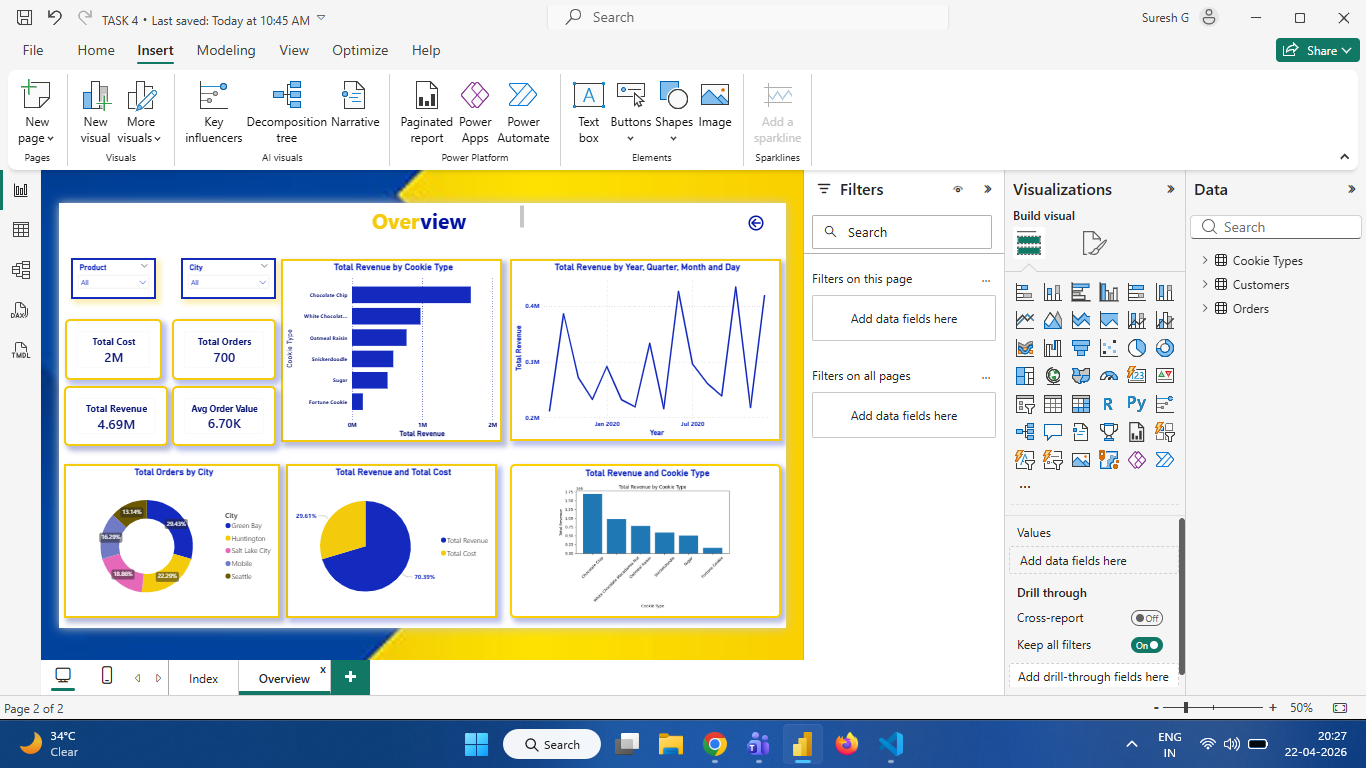

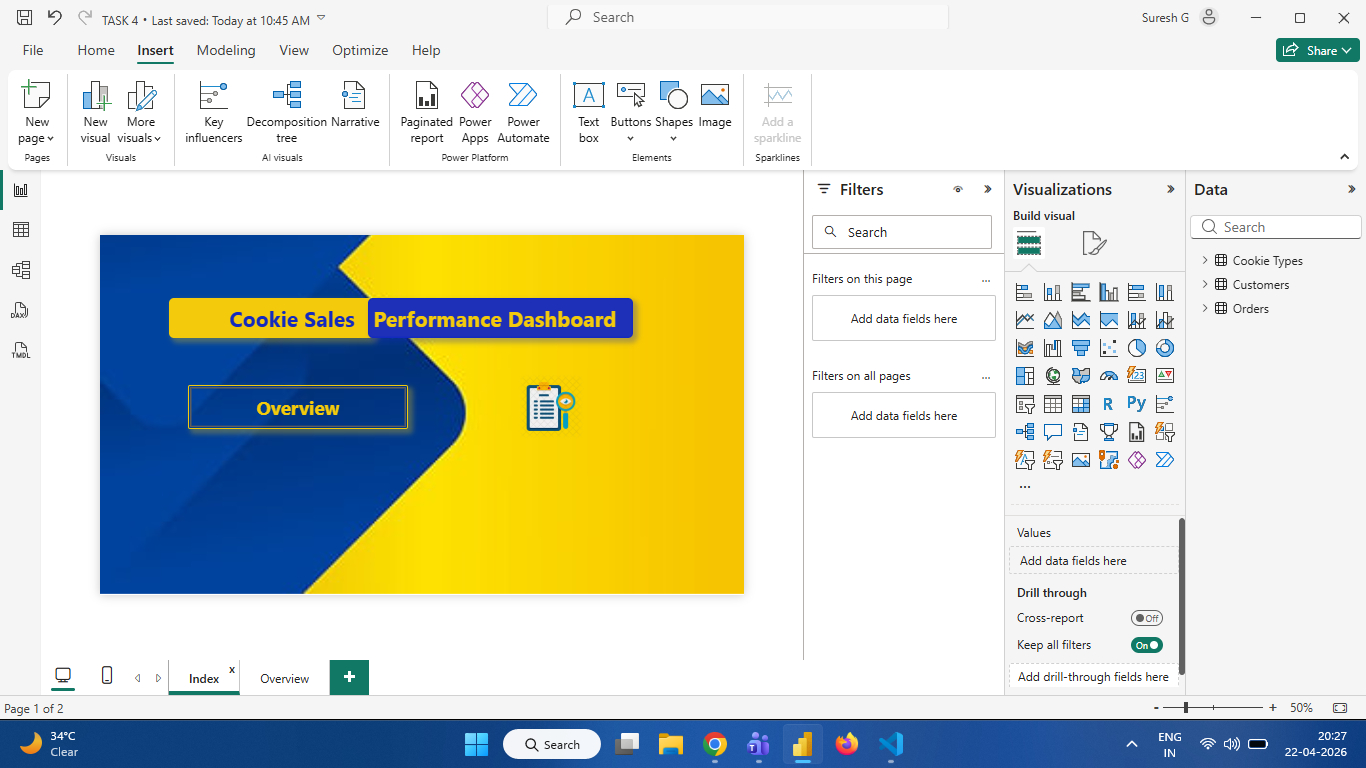

In [40]:
import os
from IPython.display import Image, display

img_path = r"C:\Users\Hp\Desktop\Projects\GitHub Projects\Cookie sales analysis\Images"

display(Image(filename=img_path + r"\Overview.png"))
display(Image(filename=img_path + r"\Index.png"))

